In [1]:
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")


In [4]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model=os.getenv("LLM_MODEL"))

In [5]:
llm.invoke("hi hello how are you?")

AIMessage(content="Hello! I'm doing great, thank you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 13, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_6f2eabb9a5', 'id': 'chatcmpl-BlwpWaXVavywRdeiCnCcWd3LekTwQ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--dab33573-1f79-4f36-b1c2-25845af4a882-0', usage_metadata={'input_tokens': 13, 'output_tokens': 16, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
from langgraph.types import Command

In [7]:
from langgraph.prebuilt import create_react_agent # we can build react agent using the prebuilt function! no need to do everything manually

In [ ]:
# class AgentState(TypedDict):
#     messages: Annotated[Sequence[BaseMessage], add_messages]
#     Name:str
#     age:int
#     DOB:int

In [8]:
def add_number(state):
    result=state["num1"]+state["num2"]
    print(f"addition is {result}")
    return Command(goto="multiply",update={"sum":result}) # update is a dictionary of key-value pairs that will be used to update the state
# goto is the name of the next node to go to

# Using Command we will be able to switch to multiple agents

In [9]:
state={"num1":10,"num2":20}

In [10]:
add_number(state)

addition is 30


Command(update={'sum': 30}, goto='multiply')

### Creating one dummy multiagent

it is for network/collab multiagent

In [11]:
from langchain_core.tools import tool

In [12]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return

In [13]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return

In [14]:
llm_with_tool=llm.bind_tools([transfer_to_addition_expert])

In [15]:
response=llm_with_tool.invoke("hi")

In [16]:
response.content

'Hello! How can I assist you today?'

In [17]:
response.tool_calls

[]

In [18]:
response=llm_with_tool.invoke("what is 2+2?")

In [19]:
response.content

''

In [20]:
response.tool_calls

[{'name': 'transfer_to_addition_expert',
  'args': {},
  'id': 'call_b3I4fXWA9yt90NBQ1V7XEEvA',
  'type': 'tool_call'}]

In [29]:
system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )

In [30]:
messages = [{"role": "system", "content": system_prompt}] + ["can you tell me the addition of 2 and 2?"]

In [31]:
messages

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

[{'role': 'system',
  'content': 'You are an addition expert, you can ask the multiplication expert for help with multiplication.Always do your portion of calculation before the handoff.'},
 'can you tell me the addition of 2 and 2?']

In [32]:
from typing_extensions import Literal
from langgraph.graph import MessagesState,StateGraph, START,END
##Agent1
def additional_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]: # we either go to multiplication_expert or end the conversation
    
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff." # handoff is delegation
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    
    ai_msg = llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    
    
    if len(ai_msg.tool_calls) > 0: # if tool was invoked, then we need to return the tool message
        tool_call_id = ai_msg.tool_calls[-1]["id"]

        #meta information 
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred to multiplication expert",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]} # if tool was triggered, then we go to multiplication_expert
        )
    return {"messages": [ai_msg]} # otherwise, return llm message

In [33]:
##Agent2
def multiplication_expert(state:MessagesState)-> Command[Literal["additional_expert", "__end__"]]: # we either go to additional_expert or end the conversation
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = llm.bind_tools([transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred to addition expert",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [34]:
graph=StateGraph(MessagesState) # workflow=StateGraph(AgentState) -> we always start our stategraph with that

In [35]:
graph.add_node("additional_expert",additional_expert)
graph.add_node("multiplication_expert",multiplication_expert)

In [36]:
graph.add_edge(START, "additional_expert") # we start from the additional_expert node
# this dummy example is collaborative (network) agent

In [37]:
app=graph.compile() # we don't need to mention conditional edges here, because we already did that in the graph construction using Command

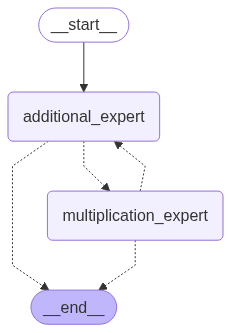

In [38]:
app

In [39]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='90ba9122-048b-4ffa-8db4-b47d7ae72531'),
  AIMessage(content="First, I'll do the addition part of the calculation:\n\n3 + 5 = 8\n\nNow, I need to multiply 8 by 12. I will ask the multiplication expert for help with that.", additional_kwargs={'tool_calls': [{'id': 'call_0Y7d4b1Ev2OIBHWacYw2r9Zt', 'function': {'arguments': '{}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 86, 'total_tokens': 144, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_6f2eabb9a5', 'id': 'chatcmpl-BlypON7U3bqDOopm5YxjExabTqPZF', 'service_tier': 'defa

## With realtime tool - Networking Agent

In [40]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [41]:
search_tool.invoke("who is a current pm of uk?")

[{'title': 'Prime Minister - GOV.UK',
  'url': 'https://www.gov.uk/government/ministers/prime-minister',
  'content': '## Contents\n\n## Responsibilities\n\nThe Prime Minister is the leader of His Majesty’s Government and is ultimately responsible for the policy and decisions of the government.\n\nAs leader of the UK government the Prime Minister also:\n\n## Current role holder\n\n### The Rt Hon Sir Keir Starmer KCB KC MP\n\nSir Keir Starmer\xa0became Prime Minister on 5 July 2024.\n\n## Education',
  'score': 0.81979275},
 {'title': 'UK Prime Minister - Facebook',
  'url': 'https://www.facebook.com/10downingstreet/',
  'content': 'UK Prime Minister. 1102952 likes · 23471 talking about this. Official page for the office of Prime Minister Keir Starmer, based at 10 Downing Street.',
  'score': 0.75049835},
 {'title': "Keir Starmer becomes new U.K. prime minister after Labour Party's ...",
  'url': 'https://www.youtube.com/watch?v=Vo4pWph_Y78',
  'content': "Voters delivered a historic bl

In [ ]:
from langchain_experimental.utilities import PythonREPL # given code in the form of string, it will execute it and return the result

In [44]:
repl=PythonREPL()

In [46]:
code = """
x = 5
y = x * 2
print(y)
"""

In [47]:
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'10\n'

In [48]:
from typing import Annotated

In [49]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )
    

<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
C:\Users\Artur Dragunov\AppData\Local\Temp\ipykernel_24412\1459227625.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\Artur Dragunov\AppData\Local\Temp\ipykernel_24412\1459227625.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [50]:
python_repl_tool

StructuredTool(name='python_repl_tool', description='Use this to execute python code. If you want to see the output of a value,\nyou should print it out with `print(...)`. This is visible to the user.', args_schema=<class 'langchain_core.utils.pydantic.python_repl_tool'>, func=<function python_repl_tool at 0x000001A9BE341800>)

In [51]:
print(python_repl_tool.invoke(code))

Successfully executed:
\`\`\`python

x = 5
y = x * 2
print(y)

\`\`\`
Stdout: 10


If you have completed all tasks, respond with FINAL ANSWER.


In [55]:
def make_system_prompt(instruction:str)->str:
    return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows when to stop."
        f"\n{instruction}"
    )

In [56]:
make_system_prompt("You can only do research. You are working with a chart generator colleague.")

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows when to stop.\nYou can only do research. You are working with a chart generator colleague."

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nYou can only do research. You are working with a chart generator colleague."

In [57]:
from langchain_core.messages import BaseMessage, HumanMessage
# BaseMessage is any user or AI message

In [58]:
def get_next_node(last_message:BaseMessage, goto:str):
    if "FINAL ANSWER" in last_message.content: # LLM sees the state and if it thinks that the work is done, it will return FINAL ANSWER which triggers the END node
        # Any agent decided the work is done
        return END
    return goto

In [59]:
#agent1 - itself is react agent
def research_node(state:MessagesState)->Command[Literal["chart_generator", END]]:
    research_agent=create_react_agent(
        llm,
        tools=[search_tool],
        prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ), 
        )
    
    result=research_agent.invoke(state)
    goto=get_next_node(result["messages"][-1],"chart_generator") # go either to chart_generator or END
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher") # we define a human message with researcher name and last result output
    return Command(update={"messages": result["messages"]},goto=goto) # update state and then go to the next node (chart_generator or END)

In [60]:
#agent2
def chart_node(state:MessagesState)-> Command[Literal["researcher", END]]:
    chart_agent=create_react_agent(
        llm, # this is reach Agent. First, we get AIMessage we chooses to use the Tool. Then we get ToolMessage. And then we get HumanMessage.
        tools=[python_repl_tool], # we use python repl tool to execute code
        prompt=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
        )
    result=chart_agent.invoke(state) # we pass entire state to the agent - all the messages. SO, we want the last message to be from Human for AI to work.  
    goto=get_next_node(result["messages"][-1],"researcher")
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator") # we are simply rewriting the last message with the name of the agent
    return Command(update={"messages": result["messages"]},goto=goto)

In [61]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()

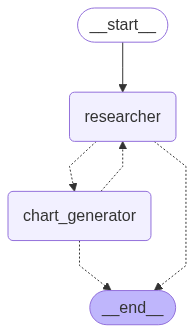

In [62]:
workflow.compile()

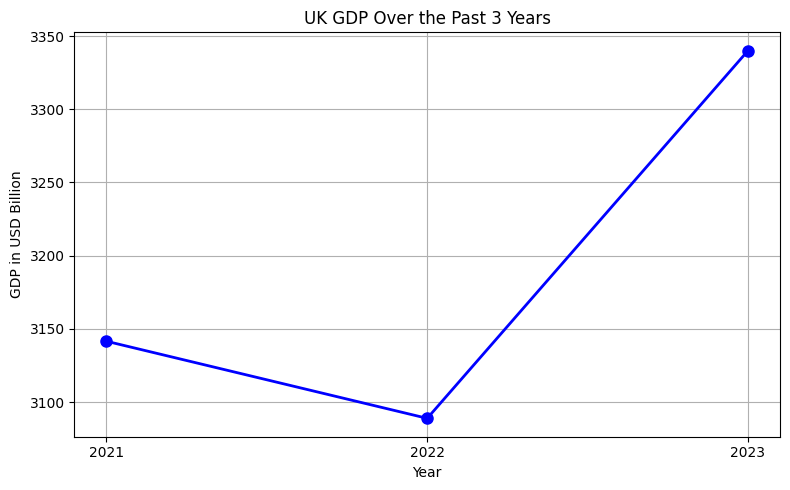

{'messages': [HumanMessage(content="get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='47d73f13-3183-4739-9af3-72c846536e96'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_r4STmDmeOKcNM8rERs1yoMdq', 'function': {'arguments': '{"query":"UK GDP over the past 3 years"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 206, 'total_tokens': 231, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_6f2eabb9a5', 'id': 'chatcmpl-BlzWhyZ2niUIez503bbIWDTdbtZB3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--2b

In [64]:
app.invoke({"messages": [("user","get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.")],})
# 1 function execution (researcher or chart_generator) creates 3 messages: First is AIMessage, then ToolMessage (these 2 come from create_react_agent), and then HumanMessage.
# AI Agent visualized the chart itself